In [2]:
import pandas as pd
import matplotlib.pyplot as plt

orders_delivered = pd.read_csv('../data/orders_delivered_clean.csv')

In [3]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders_customers = orders_delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
orders_customers.groupby('customer_state')['carrier_delivery_time'].mean()

customer_state
AC    422.695999
AL    501.608434
AM    564.212434
AP    567.924569
BA    385.357217
CE    432.685079
DF    236.567683
ES    298.394631
GO    299.259693
MA    432.879968
MG    211.438951
MS    299.524700
MT    359.647457
PA    487.237085
PB    407.864762
PE    365.257474
PI    392.838553
PR    211.797074
RJ    289.278108
RN    376.573988
RO    397.384972
RR    624.609257
RS    291.212645
SC    280.445256
SE    431.959087
SP    134.738539
TO    344.292528
Name: carrier_delivery_time, dtype: float64

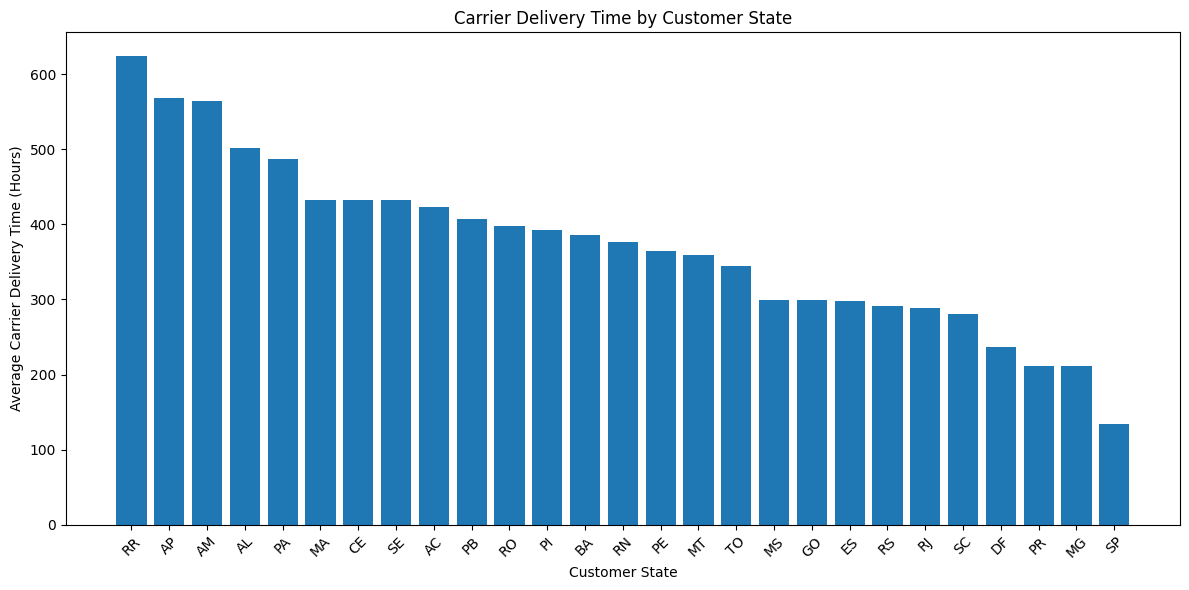

In [4]:
state_delivery = orders_customers.groupby('customer_state')['carrier_delivery_time'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(state_delivery.index, state_delivery.values)
plt.xlabel('Customer State')
plt.ylabel('Average Carrier Delivery Time (Hours)')
plt.title('Carrier Delivery Time by Customer State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
orders_customers['order_delivered_carrier_date'] = pd.to_datetime(orders_customers['order_delivered_carrier_date'])
orders_customers['carrier_month'] = orders_customers['order_delivered_carrier_date'].dt.month
orders_customers.groupby('carrier_month')['carrier_delivery_time'].mean()


carrier_month
1     245.137091
2     296.459182
3     301.014236
4     228.777964
5     206.936033
6     182.012165
7     171.424221
8     151.245932
9     207.641116
10    196.894282
11    255.444522
12    287.904390
Name: carrier_delivery_time, dtype: float64

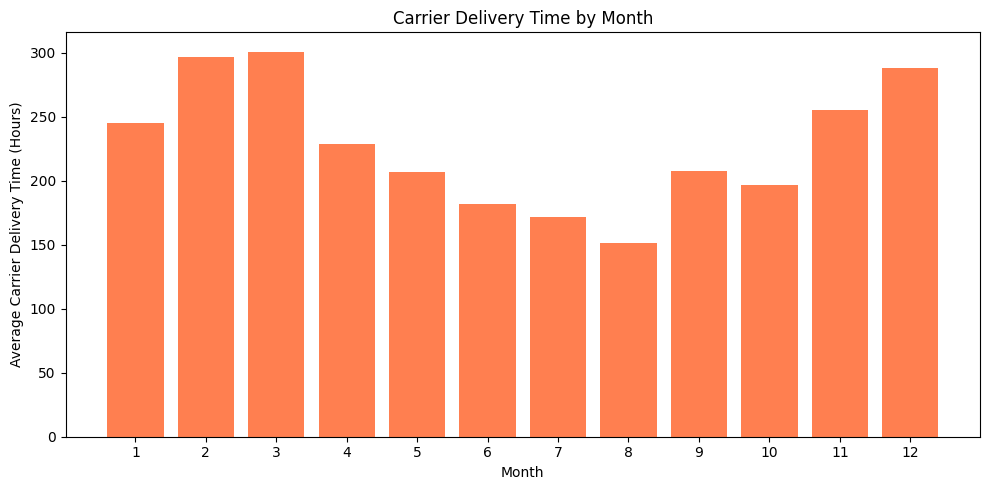

In [9]:
monthly_delivery = orders_customers.groupby('carrier_month')['carrier_delivery_time'].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_delivery.index, monthly_delivery.values, color='coral')
plt.xlabel('Month')
plt.ylabel('Average Carrier Delivery Time (Hours)')
plt.title('Carrier Delivery Time by Month')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [11]:
orders_customers['carrier_dayofweek'] = orders_customers['order_delivered_carrier_date'].dt.dayofweek
orders_customers.groupby('carrier_dayofweek')['carrier_delivery_time'].mean()

carrier_dayofweek
0    209.446782
1    220.493830
2    224.606537
3    230.033752
4    238.131432
5    268.227750
6    131.034853
Name: carrier_delivery_time, dtype: float64

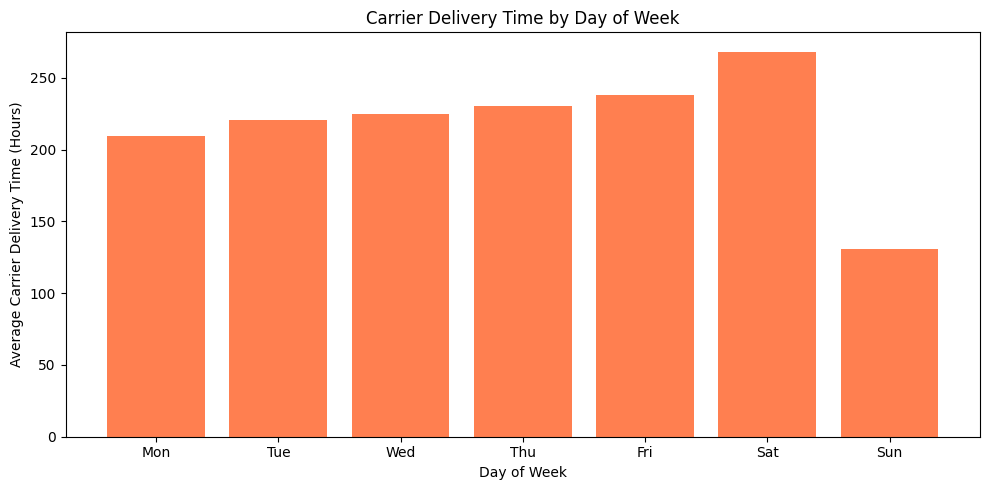

In [12]:
orders_customers['carrier_dayofweek'] = orders_customers['order_delivered_carrier_date'].dt.dayofweek

dayofweek_delivery = orders_customers.groupby('carrier_dayofweek')['carrier_delivery_time'].mean()

plt.figure(figsize=(10, 5))
plt.bar(dayofweek_delivery.index, dayofweek_delivery.values, color='coral')
plt.xlabel('Day of Week')
plt.ylabel('Average Carrier Delivery Time (Hours)')
plt.title('Carrier Delivery Time by Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.tight_layout()
plt.show()

In [13]:
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

# orders_customers + items merge
orders_products = orders_customers.merge(items[['order_id', 'product_id']], on='order_id', how='left')

# products merge
orders_products = orders_products.merge(products[['product_id', 'product_category_name', 'product_weight_g']], on='product_id', how='left')

# translation merge
orders_products = orders_products.merge(translation, on='product_category_name', how='left')

print(orders_products.shape)

(108581, 20)


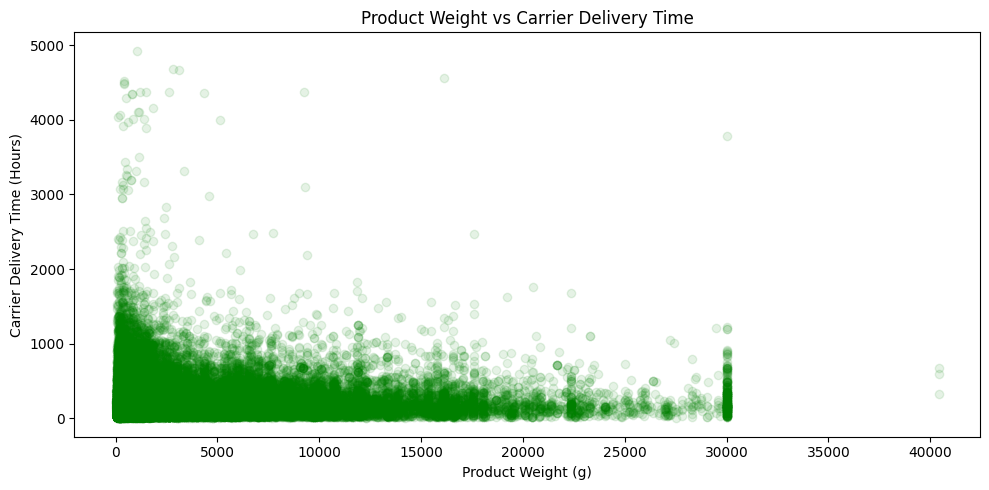

In [16]:
plt.figure(figsize=(10, 5))
plt.scatter(orders_products['product_weight_g'], orders_products['carrier_delivery_time'], alpha=0.1, color='green')
plt.xlabel('Product Weight (g)')
plt.ylabel('Carrier Delivery Time (Hours)')
plt.title('Product Weight vs Carrier Delivery Time')
plt.tight_layout()
plt.show()

In [17]:
print(orders_products[['product_weight_g', 'carrier_delivery_time']].corr())

                       product_weight_g  carrier_delivery_time
product_weight_g               1.000000               0.030591
carrier_delivery_time          0.030591               1.000000


In [18]:
category_delivery = orders_products.groupby('product_category_name_english')['carrier_delivery_time'].mean().sort_values(ascending=False)

print(category_delivery.head(10))
print()
print(category_delivery.tail(10))

product_category_name_english
security_and_services                323.635000
christmas_supplies                   299.979295
home_comfort_2                       292.566269
furniture_mattress_and_upholstery    282.641682
home_confort                         259.082098
garden_tools                         253.186684
audio                                249.400714
electronics                          244.235401
computers                            242.297088
dvds_blu_ray                         241.941252
Name: carrier_delivery_time, dtype: float64

product_category_name_english
art                          176.430044
drinks                       174.625786
fashio_female_clothing       172.234772
party_supplies               170.168413
fashion_childrens_clothes    166.833611
diapers_and_hygiene          159.984595
construction_tools_lights    155.306773
la_cuisine                   147.416766
books_imported               126.328828
arts_and_craftmanship         82.681329
Name: carrier_d

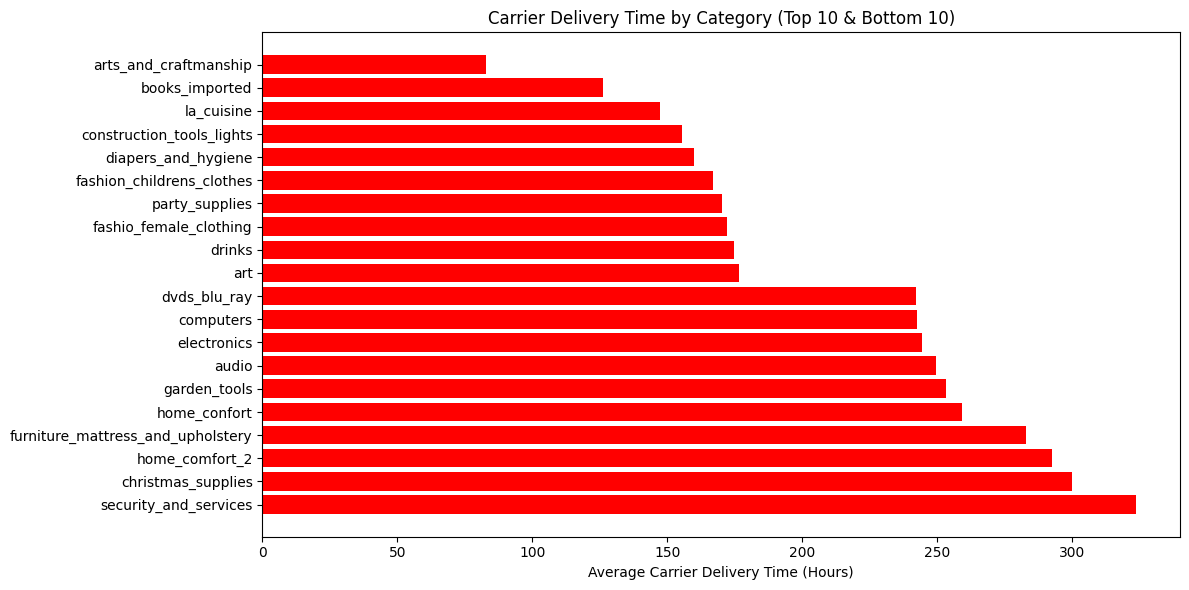

In [33]:
top10 = category_delivery.head(10)
bottom10 = category_delivery.tail(10)
combined = pd.concat([top10, bottom10])

plt.figure(figsize=(12, 6))
plt.barh(combined.index, combined.values, color='red')
plt.xlabel('Average Carrier Delivery Time (Hours)')
plt.title('Carrier Delivery Time by Category (Top 10 & Bottom 10)')
plt.tight_layout()
plt.show()

In [30]:
from scipy import stats

# customer_state ANOVA
groups_state = [group['carrier_delivery_time'].values for name, group in orders_customers.groupby('customer_state')]
f_state, p_state = stats.f_oneway(*groups_state)
print(f"customer_state - F: {f_state:.2f}, p-value: {p_state:.4f}")

# carrier_month ANOVA
groups_month = [group['carrier_delivery_time'].values for name, group in orders_customers.groupby('carrier_month')]
f_month, p_month = stats.f_oneway(*groups_month)
print(f"carrier_month - F: {f_month:.2f}, p-value: {p_month:.4f}")

# carrier_dayofweek ANOVA
groups_day = [group['carrier_delivery_time'].values for name, group in orders_customers.groupby('carrier_dayofweek')]
f_day, p_day = stats.f_oneway(*groups_day)
print(f"carrier_dayofweek - F: {f_day:.2f}, p-value: {p_day:.4f}")

# product_weight 상관관계
clean = orders_products[['product_weight_g', 'carrier_delivery_time']].dropna()
corr, p_corr = stats.pearsonr(clean['product_weight_g'], clean['carrier_delivery_time'])
print(f"product_weight_g - 상관계수: {corr:.4f}, p-value: {p_corr:.4f}")

# category ANOVA
clean_cat = orders_products[['product_category_name_english', 'carrier_delivery_time']].dropna()
groups_cat = [group['carrier_delivery_time'].values for name, group in clean_cat.groupby('product_category_name_english')]
f_cat, p_cat = stats.f_oneway(*groups_cat)
print(f"product_category - F: {f_cat:.2f}, p-value: {p_cat:.4f}")

def eta_squared(groups):
    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)
    ss_total = np.sum((all_values - grand_mean) ** 2)
    ss_between = np.sum([len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups])
    return ss_between / ss_total

import numpy as np

print(f"customer_state η²: {eta_squared(groups_state):.4f}")
print(f"carrier_month η²: {eta_squared(groups_month):.4f}")
print(f"carrier_dayofweek η²: {eta_squared(groups_day):.4f}")
print(f"product_category η²: {eta_squared(groups_cat):.4f}")

customer_state - F: 919.10, p-value: 0.0000
carrier_month - F: 526.78, p-value: 0.0000
carrier_dayofweek - F: 45.34, p-value: 0.0000
product_weight_g - 상관계수: 0.0306, p-value: 0.0000
product_category - F: 10.50, p-value: 0.0000
customer_state η²: 0.2009
carrier_month η²: 0.0574
carrier_dayofweek η²: 0.0029
product_category η²: 0.0068


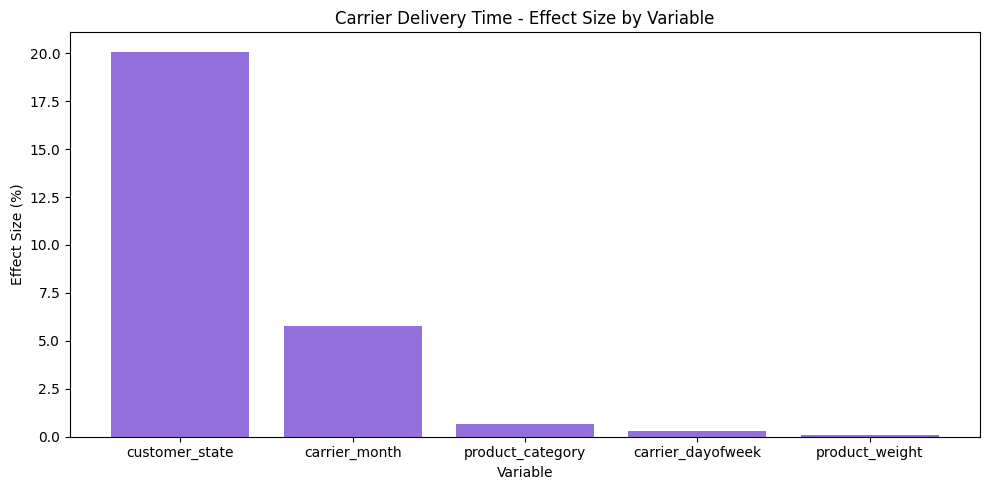

         variable  effect_size_pct
   customer_state        20.089348
    carrier_month         5.744896
 product_category         0.682335
carrier_dayofweek         0.285320
   product_weight         0.093579


In [36]:
effect_sizes = {
    'customer_state': eta_squared(groups_state) * 100,
    'carrier_month': eta_squared(groups_month) * 100,
    'product_category': eta_squared(groups_cat) * 100,
    'carrier_dayofweek': eta_squared(groups_day) * 100,
    'product_weight': (corr ** 2) * 100
}

effect_df = pd.DataFrame(list(effect_sizes.items()), columns=['variable', 'effect_size_pct'])
effect_df = effect_df.sort_values('effect_size_pct', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(effect_df['variable'], effect_df['effect_size_pct'], color='mediumpurple')
plt.xlabel('Variable')
plt.ylabel('Effect Size (%)')
plt.title('Carrier Delivery Time - Effect Size by Variable')
plt.tight_layout()
plt.show()

print(effect_df.to_string(index=False))